In [196]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")
# %matplotlib widget
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fft2, ifft, ifft2, fftfreq, fftshift
import pandas as pd
import sympy as sy
from sympy import sin, exp, cos
from IPython.display import display, Markdown
from tqdm import tqdm

plt.rcParams.update({
     "font.family": "serif",             
    "mathtext.fontset": "cm",
    "font.size": 12,                
    "axes.titlesize": 16,           
    "axes.labelsize": 16,           
    "xtick.labelsize": 10,          
    "ytick.labelsize": 10,          
    "legend.fontsize": 10,          
    "lines.linewidth": 2,           
    "axes.grid": True,              
    "grid.linestyle": "--",         
    "grid.alpha": 0.6, 
})

### Oppgave 1.1

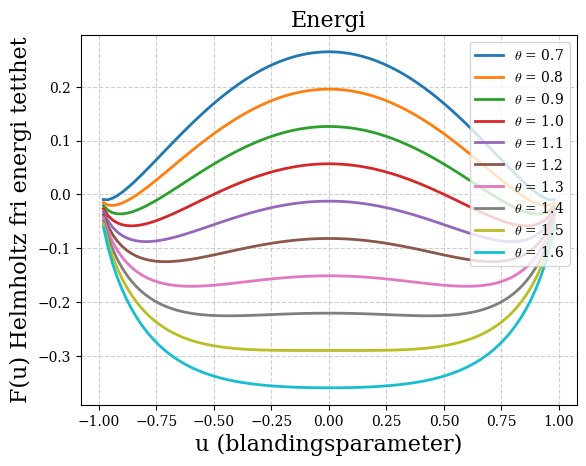

In [118]:
#logartihmic potential
temperatur_thetas = np.arange(0.7,1.7,0.1)
u = np.linspace(-1,1,100)
critical_temperature = 1.5

def log_potential(u,theta):
    l1 = (critical_temperature/2)*(1-u**2)
    l2 = (theta/2)*((1-u)*np.log((1-u)/2)+(1+u)*np.log((1+u)/2))
    return l1 + l2

for theta in temperatur_thetas:
    y_vals = log_potential(u,theta)
    plt.plot(u,y_vals, label = fr'$\theta$ = {np.round(theta,2)}')
    plt.legend(loc='upper right')

plt.title("Energi")
plt.xlabel("u (blandingsparameter)")
plt.ylabel("F(u) Helmholtz fri energi tetthet")
plt.show()

Ved lavere temperaturer enn kritisk temperatur $\theta_c$, ser vi at minimumspunktene er separert av en potensialbarriere. Dette beskriver en tilstand hvor energien minimeres dersom blandingen separeres i to forskjellige faser. For høyere temperaturer forsvinner potensialbarrieren, og vi får en konveks funksjon. Nå minimeres energien dersom vi har en perfekt blanding mellom de to fasene

### Oppgave 1.2

Vi skal vise at Cahn–Hilliard-likningen er invariant under transformasjonen  
$ u(x,t) \mapsto -u(x,t) $.  
Det vil si at hvis $ u(x,t) $ er en løsning, så er også $ -u(x,t) $ en løsning.

#### Cahn–Hilliard-ligningen

$\partial_t u - \nabla \cdot (M\nabla(f(u)-\kappa\Delta u)) = g$

#### Vil vise at -u(x,t) er en løsning dersom u(x,t) er en løsning.

Den deriverte er en lineær operator. Dette betyr at $\partial_t (-u) = -\partial_t u$. 

$\Delta u = \partial^2_x u + \partial^2_y u$, som er en operator som kun består av deriverte og addisjon, som også er lineære operatorer $\Rightarrow$ Laplace operatoren er lineær og $\Delta(-u) = -\Delta u$.

$\Delta^2 u = \Delta(\Delta(u))$, som er en operator som kun består av Laplace operatoren, som er lineær $\Rightarrow$ Den harmoniske operatoren er lineær og $\Delta^2(-u) = -\Delta^2 u$.

$f(u) = -\theta_c u + \frac{\theta}{2}\ln{\frac{1+u}{1-u}} \Rightarrow f(-u) = -\theta_c (-u) + \frac{\theta}{2}\ln{\frac{1+(-u)}{1-(-u)}} = \theta_c u + \frac{\theta}{2}\ln{\frac{1-u}{1+u}} = \theta_c u - \frac{\theta}{2}\ln{\frac{1+u}{1-u}} = -(-\theta_c u + \frac{\theta}{2}\ln{\frac{1+u}{1-u}}) \Rightarrow f(-u) = -f(u)$

Cahn-Hilliard-likningen består kun av operatorer og funksjoner som oppfyller at $ u(x,t) \mapsto -u(x,t) \Rightarrow $ Dersom $u(x,t)$ er en løsning er også $-u(x,t)$ også en løsning.

### Oppgave 1.3

Vi skal vise at systemets masse forblir konstant ved endring i tid. Altså vi vil vise at:

$\frac{d}{dt}\int_{\Omega} u(\mathbf{x},t) \,d\mathbf{x} = 0$

Det kan vises at: $\frac{d}{dt}\int_{\Omega} u(\mathbf{x},t) \,d\mathbf{x} = \int_{\Omega} \frac{d}{dt}  u(\mathbf{x},t) \,d\mathbf{x}$

Vi vet at $\partial_t u = M\Delta \mu \Rightarrow \int_{\Omega} M\Delta \mu \,d\mathbf{x} = 0$. Vi antar videre at $M = 1$

Ved bruk av divergensteoremet kan vi si at:

$\int_{\Omega} \Delta \mu \,d\mathbf{x} = \oint_{\partial \Omega} \nabla\mu \cdot \mathbf{\hat{N}} \,ds$

$\oint_{\partial \Omega} (\frac{\partial \mu}{\partial x},\frac{\partial \mu}{\partial y}) \cdot \hat{\mathbf{N}} \,ds = \int_{0}^{L_y} \nabla \mu(0, y) \cdot (0,-1) \,dy + \int_{0}^{L_x} \nabla \mu(x, 0) \cdot (-1,0) \,dx + \int_{0}^{L_y} \nabla \mu(L_x, y) \cdot (0,1) \,dy + \int_{0}^{L_x} \nabla \mu(x, L_y) \cdot (1,0) \,dx$

$\mu$ er periodisk, dette gir at $\mu(0, y) = \mu(L_x, y)$ og $\mu(x, 0) = \mu(x, L_y)$. Integralet forenkles derfor til:

$\int_{0}^{L_y} -\frac{\partial \mu}{dy} \,dy + \int_{0}^{L_x} -\frac{\partial \mu}{dx} \,dx + \int_{0}^{L_y} \frac{\partial \mu}{dy} \,dy + \int_{0}^{L_x} \frac{\partial \mu}{dy} \,dx = 0$. Herved vist.

$\frac{d}{dt}\int_{\Omega} u(\mathbf{x},t) \,d\mathbf{x} = 0 \Rightarrow \int_{\Omega} u(\mathbf{x},t) = konstant$. Massen er konstant over tid.

### Oppgave 2

In [119]:
def biharmonic_solver(X, Y, F, c, mean):
    x, y = X[:,0], Y[0,:]
    Nx, Ny = len(x), len(y)
    dx, dy = x[1] - x[0], y[1] - y[0]

    F_hat = fft2(F)
    kx = fftfreq(Nx, d=dx/ (2 * np.pi))
    ky = fftfreq(Ny, d=dy/ (2 * np.pi))
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2+KY**2
    KfourierSpace = (K2**2 + c)

    # Håndterer deling på null
    # Finn minste ikke-null verdi i K2
    K2_nonzero = K2[K2 > 0]
    k_min = np.sqrt(np.min(K2_nonzero))
    #Sjekk om c er null
    tol = 1e-14
    if c < tol * k_min**4:
        KfourierSpace[0,0] = 1

    u_hat = F_hat/KfourierSpace
    u_hat[0,0] = mean

    U = ifft2(u_hat).real

    return U

In [120]:
#parametere:
Nx1 = np.array([4,8,15,16,20,32])
Ny1 = 2*Nx1

k = np.arange(0,10)
Nx2 = 4+4*k
Ny2 =2*Nx2

Lx,Ly = 2 * np.pi, 4 * np.pi
mean = 0


In [121]:
#beregner høyreside: 
def manufacture_solution_biharmonic(u_string, c):
    x, y = sy.symbols('x y')
    u_symbolic = eval(u_string)

    laplace = lambda u: sy.diff(u, x, 2) + sy.diff(u, y, 2)
    
    #beregner dobbel laplace på funksjonen (laplace^2)
    firstLaplace = laplace(u_symbolic)
    biharmonic = laplace(firstLaplace)
    f_symbolic = biharmonic + c*u_symbolic
    f_symbolic = sy.simplify(f_symbolic)

    u = sy.lambdify((x, y), u_symbolic, modules='numpy')
    f = sy.lambdify((x, y), f_symbolic, modules='numpy')

    return u,f

In [122]:
u1_string = 'sin(8*(x-1))*cos(4*y)'
u1,f1 = manufacture_solution_biharmonic(u1_string, c = 1)

u2_string = 'exp(sin(x)**2+cos(2*y))'
u2,f2 = manufacture_solution_biharmonic(u2_string, c = 0)

In [123]:
def compute_errors(f,NX,NY,u,c):
    errors = []
    eocs = []
    for i in range(len(NX)):
        Lx = 2*np.pi
        Ly = 4*np.pi
        Nx = NX[i]
        Ny = NY[i]
        x = np.linspace(0,Lx,Nx, endpoint=False)
        y = np.linspace(0,Ly,Ny, endpoint=False)
        X,Y = np.meshgrid(x,y, indexing="ij")

        F = f(X,Y)
        U_ex = u(X,Y)
        U = biharmonic_solver(X, Y, F, c, mean)
        U += np.mean(U_ex)
        U_err = U - U_ex
        error = np.linalg.norm(U_err, np.inf)
        errors.append(error)

        if len(errors) > 1:
            h_now = Lx / NX[i]
            h_prev = Lx / NX[i-1]
            eoc = np.log(errors[-1] / errors[-2]) / np.log(h_now / h_prev)
            eocs.append(eoc)
        else:
            eocs.append("Not yet...")

    return errors,eocs
        
errors1, eocs1 = compute_errors(f1,Nx1,Ny1,u1,c=1)
errors2, eocs2 = compute_errors(f2,Nx2,Ny2,u2,c=0)

In [124]:
df1 = pd.DataFrame({
    'Nx': Nx1,
    'Ny': Ny1,
    'Feil': errors1,
    'EOC': eocs1
})


df2 = pd.DataFrame({
    'Nx': Nx2,
    'Ny': Ny2,
    'Feil': errors2,
    'EOC': eocs2
})

display(Markdown(r"### Resultater for $u_1$:"))
display(df1)
display(Markdown(r"### Resultater for $u_2$:"))
display(df2)

### Resultater for $u_1$:

,Nx,Ny,Feil,EOC
0,4,8,1.818989e-12,Not yet...
1,8,16,3.784353e+02,-47.563903
2,15,30,9.827684e+00,5.807813
3,16,32,7.863653e-14,502.942163
4,20,40,6.159517e-13,-9.224252
5,32,64,1.001514e-12,-1.034246


### Resultater for $u_2$:

,Nx,Ny,Feil,EOC
0,4,8,9.573099e+01,Not yet...
1,8,16,8.456927e+01,0.178852
2,12,24,1.123358e+01,4.978638
3,16,32,3.294907e-01,12.267412
4,20,40,1.254177e-02,14.647448
5,24,48,7.612873e-04,15.367403
6,28,56,4.102912e-05,18.947233
7,32,64,2.124529e-06,22.172552
8,36,72,9.783264e-08,26.133196
9,40,80,4.265664e-09,29.732775


$f(x) = sin(8(x-1))cos(4y)$ har maskimalfrekvenser $f_x = \frac{8}{2\pi}$ og $f_y = \frac{4}{2\pi}$. For å unngå aliasing trenger vi en samplingsfrekvens som er minst 2 ganger så stor som maksimalfrekvensen. Samplingsfrekvensen, $f_{sampling} = \frac{N_x}{L_x}$. For å unngå aliasing trenger vi at $\frac{N_x}{L_x} \geq 2\frac{8}{2\pi}$ og $\frac{N_y}{L_y} \geq 2\frac{4}{2\pi}$. Med $L_x = 2\pi$ og $L_y = 4\pi$ får vi at $N_x \geq 16$ og $N_y \geq 16$. Altså trenger vi 16 eller mer samplingspunkter for å ikke få aliasing. Dette gjenspeiler seg i resultatene. Når vi har har mindre enn 16 samplingspunkter fanges ikke de største frekvensene opp, og vi får store feil. For 16 samplingspunkter eller mer fanges alle frekvensene opp, og vi får ekstremt presise løsninger med minimiale feil. $f(x) = exp(sin^2(x)+cos(2y))$ har maskimalfrekvenser $f_x = \frac{1}{2\pi}$ og $f_y = \frac{4}{2\pi}$. For å unngå aliasing trenger vi at $N_x \geq 2$. Ettersom vi kun tester funksjonen for fire eller mer samplingspunkter, får vi aldri aliasing. Jo fler samplingspunkter vi bruker jo større konvergensrate får vi.

In [146]:
def plot_solutions_all(Nx_list, Ny_list, Lx, Ly, f,u_exact, c):
    """
    Plotter (Exact, Numerical, Error) i hver sin kolonne for hver (Nx, Ny).
    Antall rader = len(Nx_list), antall kolonner = 3.
    """

    # Antall rader og kolonner i subplot-ruten
    nrows = len(Nx_list)
    ncols = 3

    # Opprett en figur med riktig antall akser (3D-subplots).
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(12, 4*nrows),
                             subplot_kw={'projection': '3d'})

    # Hvis nrows == 1, blir axes en 1D-array på [3,], vi gjør den 2D for enkel looping.
    if nrows == 1:
        axes = np.array([axes])

    for i, (Nx, Ny) in enumerate(zip(Nx_list, Ny_list)):
        # Bygg rutenett
        x = np.linspace(0, Lx, Nx, endpoint=False)
        y = np.linspace(0, Ly, Ny, endpoint=False)
        X, Y = np.meshgrid(x, y, indexing="ij")

    
        # Løs med din biharmoniske solver
        U = biharmonic_solver(X, Y, f(X, Y), c, mean=0.0)
        # Justér mean om nødvendig (avhenger av PDE-setup)
        U += np.mean(u_exact(X, Y))

        error = np.abs(u_exact(X, Y) - U)




        # ============== Exact =================
        ax1 = axes[i, 0]
        surf1 = ax1.plot_surface(X, Y, u_exact(X, Y),
                                 cmap='viridis', edgecolor='none')
        min = np.min(u_exact(X, Y))
        max = np.max(u_exact(X, Y))
        ax1.set_title(fr'Exact ($N_x={Nx}$, $N_y={Ny}$)')

        sm = plt.cm.ScalarMappable(cmap='viridis')
        sm.set_array([])  
        sm.set_clim(min, max)
        fig.colorbar(sm, ax=ax1,shrink=0.5, aspect=10, pad=0.1)

        # ============== Numerical =============
        ax2 = axes[i, 1]
        surf2 = ax2.plot_surface(X, Y, U,
                                 cmap='viridis', edgecolor='none')
        ax2.set_title(fr'Numerical ($N_x={Nx}$, $N_y={Ny}$)')
        min = np.min(U)
        max = np.max(U)

        sm = plt.cm.ScalarMappable(cmap='viridis')
        sm.set_array([])  
        sm.set_clim(min, max)
        fig.colorbar(sm, ax=ax2,shrink=0.5, aspect=10, pad=0.1)
    

        # ============== Error =================
        ax3 = axes[i, 2]
        surf3 = ax3.plot_surface(X, Y, error,
                                 cmap='hot', edgecolor='none')
        ax3.set_title(f'Error (max={np.max(error):.2e})')
        fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10, pad=0.1)

    plt.tight_layout()
    plt.show()

### Løsning for $u_1$:

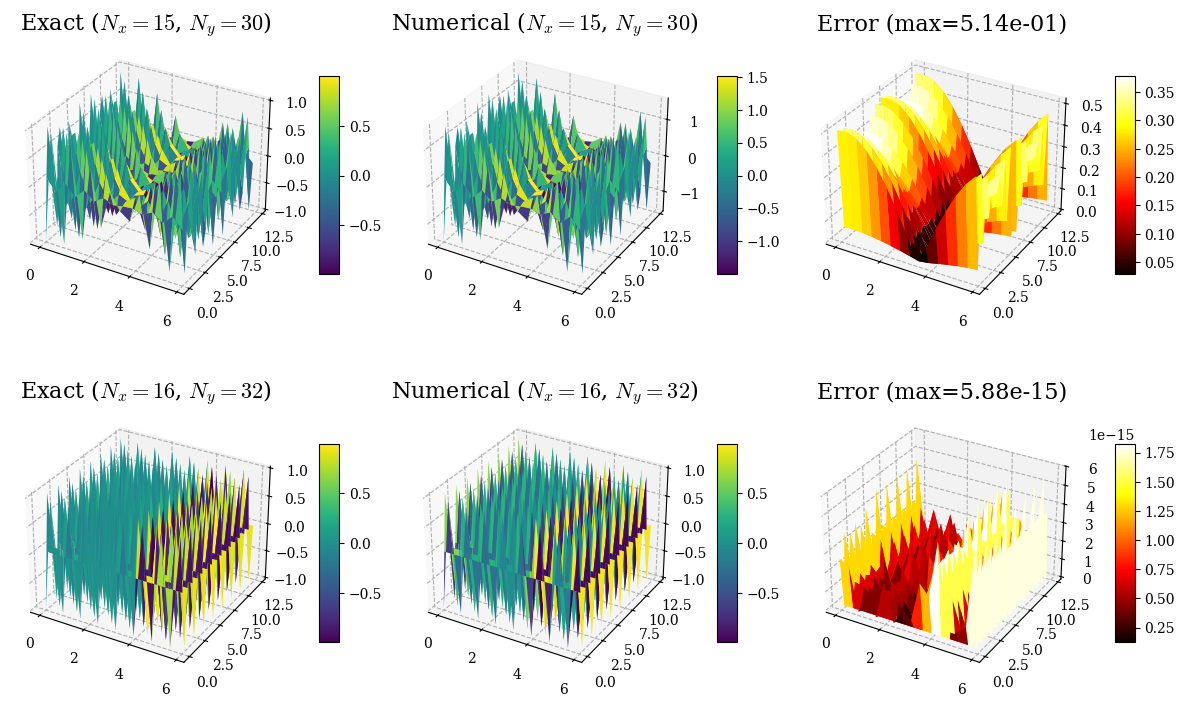

### Løsning for $u_2$:

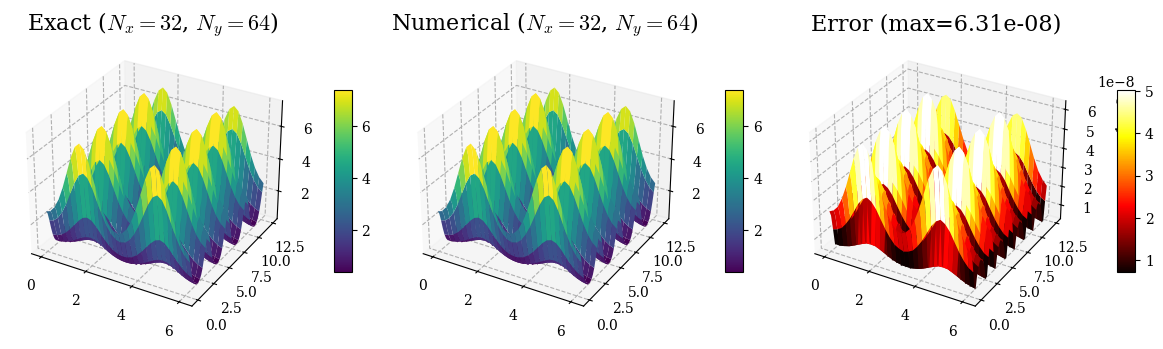

In [147]:
Nx_list = np.array([15, 16])
Ny_list = Nx_list*2
Lx,Ly = 2 * np.pi, 4 * np.pi
display(Markdown(r"### Løsning for $u_1$:"))
plot_solutions_all(Nx_list,Ny_list,Lx,Ly,f1,u1,c=1)

Nx_list = np.array([32])
Ny_list = 2*Nx_list
display(Markdown(r"### Løsning for $u_2$:"))
plot_solutions_all(Nx_list, Ny_list, Lx,Ly,f2, u2,c = 0)

## Oppgave 3 teoridel

### Oppgave 3.1

Vi begynner med $\theta$  - metoden; den er definert slik:

$
U^{n+1} = U^n + \tau \left( \theta F(t_{n+1}, U^{n+1}) + (1 - \theta) F(t_n, U^n) \right), \quad \text{for } n = 0, 1, 2, \dots, N - 1
$

Herifra kan vi definere $k_1$ og $k_2$:

$k_1 = F(t_n, U^n)$  
$k_2 = F(t_{n+1}, U^{n+1}) = F(t_n + \tau, U^n + \tau(\theta k_2 + (1-\theta)k_1))$ 


*Nå kan vi skrive $\theta$  - metoden slik ved å benytte $k_1$ og $k_2$:*

$U^{n+1} = U^n + \tau \cdot (\theta k_2 + (1-\theta)k_1)$    

Fra dette kan vi utlede en generell butcher tabell ved å benytte at:

$
k_j := f\left(t_k + c_j \tau,\ y_k + \tau \sum_{l=1}^{s} a_{jl} k_l\right), \quad j = 1, \dots, s,
$
  
$
y_{k+1} := y_k + \tau \sum_{j=1}^{s} b_j k_j
$


$
\begin{array}{c|cccc}
c_1 & a_{11} & a_{12} & \cdots & a_{1s} \\
c_2 & a_{21} & a_{22} & \cdots & a_{2s} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
c_s & a_{s1} & a_{s2} & \cdots & a_{ss} \\
\hline
& b_1 & b_2 & \cdots & b_s
\end{array}
$



Butcher tabellen blir da i det generelle tilfellet slik:

$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 1 - \theta & \theta \\
\hline
  & 1 - \theta & \theta
\end{array}
$

  

Fra dette observerer vi noen kjente Runge-Kutta metoder:

**Forward Euler** ( $\theta = 0$)

$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 1 & 0 \\
\hline
  & 1 & 0
\end{array}
$

**Backward Euler** ($ \theta = 1 $)

$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 0 & 1 \\
\hline
  & 0 & 1
\end{array}
$

**Crank–Nicolson** ($ \theta = \frac{1}{2} $)

$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & \frac{1}{2} & \frac{1}{2} \\
\hline
  & \frac{1}{2} & \frac{1}{2}
\end{array}
$


**Konsistensorden for ulike $\theta$**   
*For å bestemme konsistensorden avhengig av $\theta$ benytter vi tabellen i forelesningsnotatene.*  
### Betingelser for konsistensorden

| $p$ | Betingelser |
|-----|------------|
| 1   | $\sum_{i=1}^{s} b_i = 1$ |
| 2   | $\sum_{i=1}^{s} b_i c_i = \frac{1}{2}$ |
| 3   | $\sum_{i=1}^{s} b_i c_i^2 = \frac{1}{3}$  <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} b_i a_{ij} c_j = \frac{1}{6}$ |
| 4   | $\sum_{i=1}^{s} b_i c_i^3 = \frac{1}{4}$ <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} b_i c_i a_{ij} c_j = \frac{1}{8}$ <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} b_i a_{ij} c_j^2 = \frac{1}{12}$ <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} \sum_{k=1}^{s} b_i a_{ij} a_{jk} c_k = \frac{1}{24}$ |   

Det første vi kan legge merke til er at uavhengig av theta vil alle metodene ha minst konsistensorden 1.  
Dette er fordi summen av $\sum_{i=1}^{2} b_i = 1 - \theta + \theta = 1$

In [193]:
theta = np.linspace(0,1,1000)
print("Sjekker noen θ-verdier for konsistensorden:")
print("-------------------------------------")
for i in range(len(theta)):
    c1 = 0
    c2 = 1
    a11 = 0
    a12 = 0
    b1 = 1 - theta[i]
    b2 = theta[i]
    a21 = 1- theta[i]
    a22 = theta[i]
    #check for p = 2:
    sum = b1*c1+b2*c2
    if sum < 0.5005 and sum > 0.499:
        print("Sjekker for p = 2:")
        print(f"p = 2 for θ = {theta[i]:.1f}")
        print("θ = 0.5 er dermed en θ-verdi som gir konsistensorden 2!")

    #check for p = 3:

    sum1 = b1*c1**2+b2*c2**2
    if sum < 0.33334 and sum > 0.333:
        print("Sjekker for p = 3:")
        print(f"Første betingelse oppnås for θ =  {theta[i]:.3f}")
        print("Sjekker neste betingelse:")
        sum2 = b2*c2*a21 + b2*c2*a22
        print(np.round(sum2,2), " != ", np.round(1/6,2))
        print("---------------------------------------")

Sjekker noen θ-verdier for konsistensorden:
-------------------------------------
Sjekker for p = 3:
Første betingelse oppnås for θ =  0.333
Sjekker neste betingelse:
0.33  !=  0.17
---------------------------------------
Sjekker for p = 2:
p = 2 for θ = 0.5
θ = 0.5 er dermed en θ-verdi som gir konsistensorden 2!


Kodesnutten over itererer gjennom noen $\theta$-verdier og tester for konsistensorden 2 og 3.  
Ved konsistensorden 2 er det kun en verdi av $\theta$ som oppfyller betingelsene. Nemlig $\theta = \frac{1}{2}$, altså Crank-Nicholson metoden! 
Ved konsistensorden 3 oppfylles første betingelse for $\theta = \frac{1}{3}$, men denne $\theta$-verdien oppfyller ikke neste betingelse. Kan dermed konkludere med at ingen $\theta$-verdi gir konsistensorden større enn $2$.

###  Konklusjon:

- For $ \theta = 0 $: Forward Euler → orden 1
- For $ \theta = 1 $: Backward Euler → orden 1
- For $ \theta = \frac{1}{2} $: Crank–Nicolson → orden 2
- For andre verdier av $\theta $, metoden er 1. ordens nøyaktig

Det er kun $\theta = \frac{1}{2} $ som oppfyller alle betingelsene for 2. ordens konsistens.


### Oppgave 3.2

##### Utledning for stabilitetsfunksjonen $R_{\theta}(Z)$:  
Definerer $z = \lambda \tau$. 

Generelt sett er stabilitetsfunksjonen definert slik:  

$U^{n+1} = r_{\theta}(z) U^n$

Og for $\theta$ -metoden:

$
U^{n+1} = U^n + \tau \left( \theta F(t_{n+1}, U^{n+1}) + (1 - \theta) F(t_n, U^n) \right)
$

$
U^{n+1} = U^n + \tau \left( \theta \lambda U^{n+1} + (1 - \theta) \lambda U^n \right)
$

$
\frac{U^{n+1}}{U^n} = \frac{1 + \tau \lambda - \tau \theta \lambda}{1 - \tau \theta \lambda}
$

Dette blir stabilitetsfunksjonen $r_{\theta}(z)$ som vi nå skriver som:  

$r_{\theta}(z) = 1 + \frac{z}{1-z \theta}$  

Stabilitetsregionen er dermed gitt ved $|r_{\theta}(<>)| < 1 = |1 + \frac{z}{1-z \theta}| < 1$.

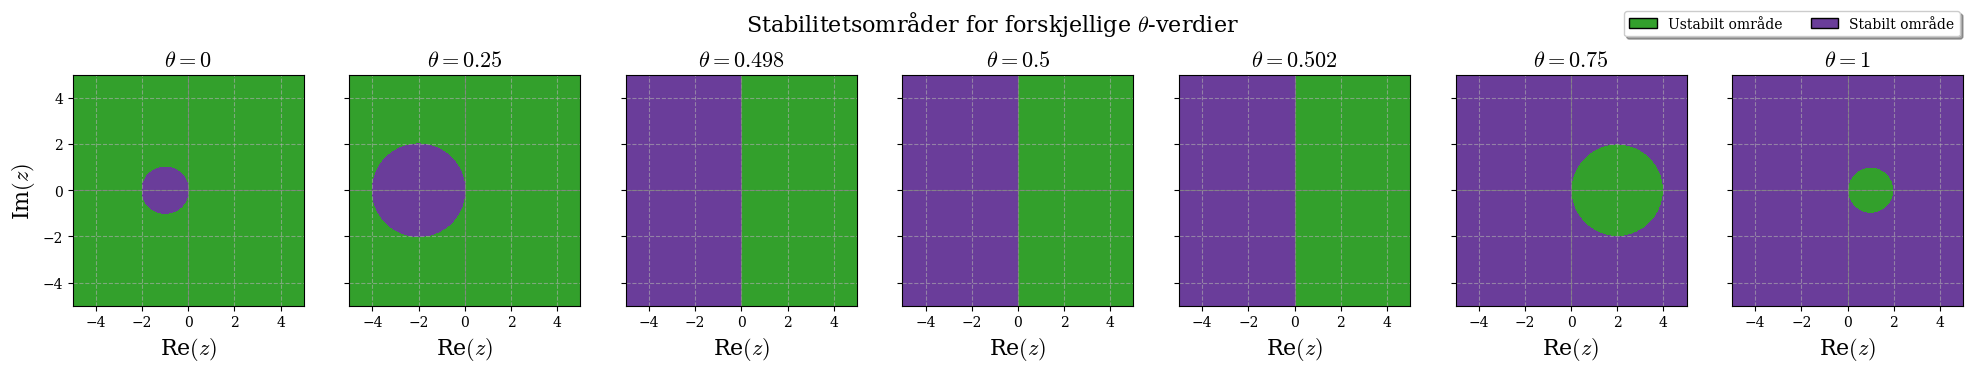

In [221]:
a = np.linspace(-5, 5, 1000)
b = np.linspace(-5, 5, 1000)
A, B = np.meshgrid(a, b)
Z = A + B * 1j

# Stabilitetsfunksjonen
def Rz(Z, theta):
    R = 1 + Z / (1 - Z * theta)
    return np.abs(R)

fig, axes = plt.subplots(1, 7, figsize=(20, 5), sharex=True, sharey=True)

# Theta-verdier
theta_vals = [0, 0.25, 0.498, 0.5, 0.502,0.75,1]

# Plot hver region på sin egen aksis
for ax, theta in zip(axes, theta_vals):
    ax.contourf(A, B, Rz(Z, theta) <= 1, cmap='Paired', levels=1)
    ax.set_title(rf"$\theta = {theta}$")
    ax.set_xlabel("Re$(z)$")
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect("equal")

axes[0].set_ylabel("Im$(z)$")
fig.suptitle("Stabilitetsområder for forskjellige $\\theta$-verdier", fontsize=16)
legend_elements = [
    Patch(facecolor='#33a02c', edgecolor='k', label='Ustabilt område'),
    Patch(facecolor='#6a3d9a', edgecolor='k', label='Stabilt område')
]
fig.legend(handles=legend_elements, loc = 'upper center', bbox_to_anchor=(0.9, 0.99),
          fancybox=True, shadow=True, ncol=2)
plt.tight_layout()
plt.subplots_adjust(top=1.2)
plt.show()


Hele det venstre halvplanet, det vil si mengden {$z \in \mathbb{C}, \text{Re}(z) \leq 0$}, ser ut til å være en del av stabilitetsområdet for $\theta > 0.5$. Dette indikerer at $\theta$-metoden er A-stabil for $\theta > 0.5$.

### Oppgave 3.3

Stabile områder gis for:
  
$r_{\theta}(z) \leq 1$

$r_{\theta}(z) = \frac{U^{n+1}}{U^n} = 1 + \frac{z}{1-z \theta}$

Grensen for stabilitetsregionen er dermed gitt ved:  

$
\partial S_\theta = \left\{ z \in \mathbb{C} \;:\; |r_\theta(z)| = 1 \right\}
$

Fra dette kan vi prøve å forenkle uttrykket:

Vi starter med:   

$|r_\theta(z)| = 1 + \frac{Z}{1-z \theta}|=  |\frac{1+z(1-\theta)}{1-z \theta}| = 1$

For komplekse brøker gjelder:

$|\frac{a}{b}| = \frac{|a|}{|b|}$

$|\frac{1+z(1-\theta)}{1-z \theta}| = 1 \iff 1+z(1-\theta)| = |1-z \theta|$  

Kvadrerer begge sidene:  

$|1+z(1-\theta)|^2 = |1-z \theta|^2$ 

Nå kan vi sette inn $x$ og $iy$ for z og oppnår:  

$|1+(x+iy)(1-\theta)|^2 = |1-(x+iy) \theta|^2$ 

Samtidig benytter vi at for et komplekst tall at:

$|w|^2 = x^2 + y^2$  

Da kan vi skrive om likninga over til:  

$[1+x(1-\theta)]^2 + [y(1-\theta)]^2 = [1-x \theta]^2+[y \theta]^2$

Nå kan vi utvide og forenkle uttrykk:

$(1 + 2x(1 - \theta) + x^2(1- \theta)^2) + y^2(1- \theta)^2 = (1 - 2x \theta + x^2 \theta^2) + y^2 \theta^2$

Vi oppnår da:

$2x + (1 - 2\theta)(x^2+y^2) = 0$

Dette likner på likningen for en sirkel og vi innfører en ny variabel $\beta$ for å forenkle og fullfører kvadratet:  

$\beta = 1 - 2\theta$

$\frac{2x}{\beta} + x^2 + y^2 = 0$

Vi får sirkellikninga:  

$(x+\frac{1}{{\beta}})^2 + y^2 = \frac{1}{\beta^2}$

Vi kan gjøre noen generelle observasjoner her:  
- Sentrum i sirkelen ligger i $-\frac{1}{\beta} = - \frac{1}{1 - 2\theta}$
- Radiusen til sirkelen der metoden er stabil er $r = \frac{1}{|\beta|} = \frac{1}{|1 - 2\theta|}$
- Dette medfører at $\theta > 0$ 
- $\lim_{\theta \to \frac{1}{2}^{-}} \frac{1}{1 - 2\theta} = \infty$   Når 

### Konklusjon:

For $\theta = \frac{1}{2}$ går stabilitetsregionens radius mot uendelig, dette betyr at hele venstre halvplan er A-stabilt, altså $\theta > \frac{1}{2} \rarr$ A-stabilt!

For  $\theta < \frac{1}{2}$ er stabilitetsregionen en sirkel som ikke dekker hele halvplanet, dermed er den stabil i enkelte regioner, men ikke fullstendig A-stabil.

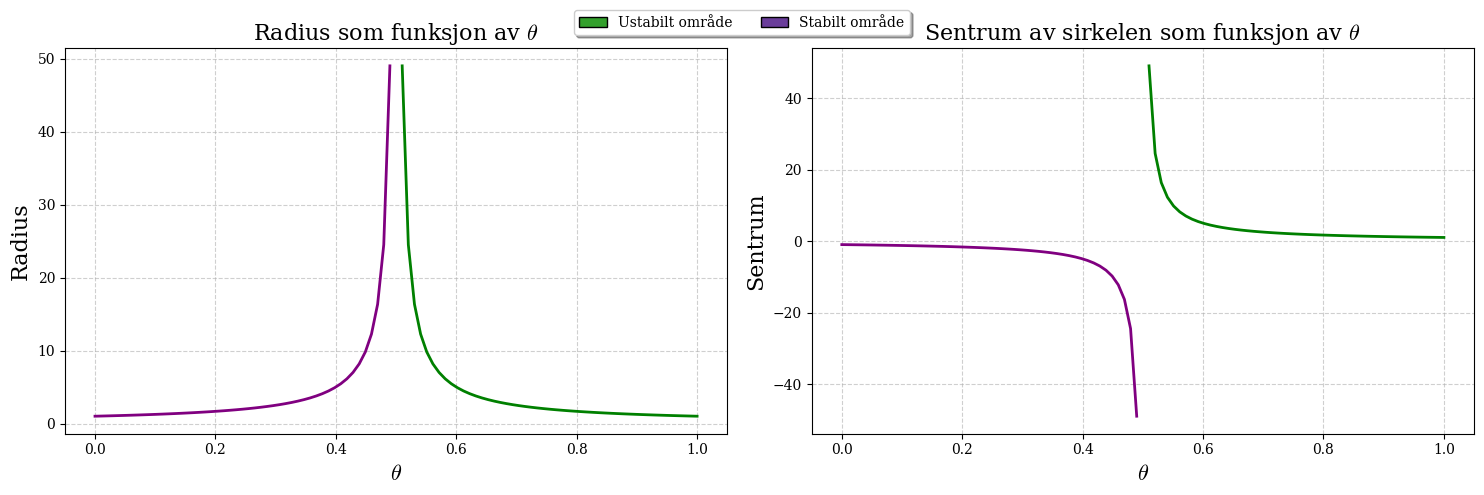

In [238]:
theta1 = np.linspace(0,0.5,50)
theta2 = np.linspace(0.5,1,50)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(theta1, 1 / (1 - 2 * theta1), color = "purple")
ax[0].plot(theta2, -1 / (1 - 2 * theta2), color = "green")
ax[0].set_title(r"Radius som funksjon av $\theta$")
ax[0].set_xlabel(r"$\theta$")
ax[0].set_ylabel(r"Radius")

ax[1].plot(theta1, -1 / (1 - 2 * theta1), color = "purple")
ax[1].plot(theta2, -1 / (1 - 2 * theta2), color = "green")
ax[1].set_title(r"Sentrum av sirkelen som funksjon av $\theta$")
ax[1].set_xlabel(r"$\theta$")
ax[1].set_ylabel(r"Sentrum")



legend_elements = [
    Patch(facecolor='#33a02c', edgecolor='k', label='Ustabilt område'),
    Patch(facecolor='#6a3d9a', edgecolor='k', label='Stabilt område')
]
fig.legend(handles=legend_elements, loc = 'upper center', bbox_to_anchor=(0.5, 1),
          fancybox=True, shadow=True, ncol=2)

plt.tight_layout()
plt.show()

Plottet til venstre viser at for $\theta < \frac{1}{2}$ er stabilitetsområdet begrenset til en sirkel med endelig radius i det negative halvplanet. Når $\theta \rarr \frac{1}{2}$ vokser radiusen mot uendelig, noe som tilsier at hele det venstre halvplanet blir inkludert i stabilitetsområdet. Dette betyr at metoden er A-stabil for $\theta = \frac{1}{2}$. For $\theta > 0$ viser plottet at deler av det positive halvplanet blir ustabilt, men dette er ikke relevant for A-stabilitet, som kun krever stabilitet i det venstre halvplan. Metoden er dermed A-stabil for alle $\theta > \frac{1}{2}$. 

Plottet til høyre viser sentrum av stabilitetssirklene som funksjon av $\theta$. For $\theta < \frac{1}{2}$, flyttes semtrum mot mer negative verdier, og når $\theta \rarr \frac{1}{2}$ går sentrum mot $-\infty$. Dette understøtter igjen at stabilitetsområdet dekker hele det venstre halvplanet akkurat i grenseverdien $\theta = \frac{1}{2}$.

## Oppgave 3 numerisk:
### Oppgave 3.1

Vi skal benytte $\theta$-metoden;

$
U^{n+1} = U^n + \tau \left( \theta F(t_{n+1}, U^{n+1}) + (1 - \theta) F(t_n, U^n) \right)$

$
\partial_t U = F(t, U), \qquad U(t_0) = U_0
$


for å løse likningen:

$
\partial_t u + \kappa \Delta^2 u = g
$

Vi bruker likningene over til å bestemme at

$F(t, U) = g - \kappa \Delta^2 u$

I Fourierrommet får vi:

$\tilde{k} = 2 \pi (k_x,k_y)$
  
$F(t, U) = \hat{g} -\kappa |\tilde{k}|^4 \hat{u}$

deretter kan vi finne at:

$F(t_n, U^n) = \hat{g} -\kappa |\tilde{k}|^4 \hat{u}$  


$F(t_{n+1}, U^{n+1}) = \hat{g}^{n+1} -\kappa |\tilde{k}|^4 \hat{u}^{n+1}$  

vi setter inn i $\theta$ metoden og oppnår:

$\hat{u}^{n+1} = \hat{u}^{n} + \tau(\theta(\hat{g}^{n+1} -\kappa |\tilde{k}|^4 \hat{u}^{n+1}) + (1-\theta)(\hat{g} -\kappa |\tilde{k}|^4 \hat{u}))$

som kan skrives som:  

$\hat{u}^{n+1} = \frac{\hat{u}^{n}(1-\tau(1-\theta)\kappa|\tilde{k}|^4) + \tau(\theta \hat{g}^{n+1} + (1-\theta)\hat{g})}{1+\tau\theta\kappa\|\tilde{k}|^4}$

Som vi bruker i løseren vår.

In [151]:
def transient_biharmonic_solver(*,kappa,X,Y,U0,t0,T,Nt,theta,g = None):
    x, y = X[0,:], Y[:,0]
    Nx, Ny = len(x), len(y)
    dx, dy = x[1] - x[0], y[1] - y[0]


    #beregner kx og ky i frekvensrommet
    kx = fftfreq(Nx, d=dx/(2*np.pi))
    ky = fftfreq(Ny, d=dy/(2*np.pi))
    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    #biharmonisk operator i frekvensrommet:
    K4 = (KX**2+KY**2)**2

    #time stepping
    t = t0
    dt = (T-t0)/Nt
    U_hat = fft2(U0)

    #returnerer startbetingelsene
    yield (U_hat, t)
    
    with tqdm(total=T) as pbar:
        while t < T-dt/2:
            if g is not None:
                G_hat = fft2(g(X,Y,t))
                G_hat_next = fft2(g(X,Y,t+dt))
            else:
                G_hat = 0
                G_hat_next = 0

            U_hat = (U_hat*(1-dt*(1-theta)*kappa*K4) + (dt*((theta*G_hat_next)+((1-theta)*G_hat))))/(1+dt*theta*kappa*K4)
            
            t = t + dt
            pbar.update(dt)
            yield U_hat, t

In [152]:
#manufacture solutions
def manufacture_solution_transistent(u_string,kappa):

    x, y, t = sy.symbols('x y t')
    u_symbolic = eval(u_string)

    laplace = lambda u: sy.diff(u, x, 2) + sy.diff(u, y, 2)
    
    #beregner dobbel laplace på funksjonen (laplace^2)
    firstLaplace = laplace(u_symbolic)
    biharmonic = laplace(firstLaplace)
    g_symbolic = kappa*biharmonic + sy.diff(u_symbolic,t,1) 

    u = sy.lambdify((x, y, t), u_symbolic, modules='numpy')
    g = sy.lambdify((x, y, t), g_symbolic, modules='numpy')
    print(f'u = {u_symbolic}')
    print(f'u0 = {u_symbolic.subs(t, 0)}')
    print(f'g = {g_symbolic}')

    return u,g

In [153]:
#løsningsforberedelser
Lx,Ly = np.pi,np.pi
Nx,Ny = 20,20
x = np.linspace(-Lx,Lx,Nx,endpoint=False)
y = np.linspace(-Ly,Ly,Ny,endpoint=False)
X,Y = np.meshgrid(x,y,sparse=True)

#parametere
kappa = 1
T,t0 = 1,0

#velger lambda lik 4, da blir g(x,y,t) lik 0
lamb = 4
Nt_list = [10,20,40,80,160,320,640]
g = None

#string representasjon av funksjonen
u_string_ex = 'sin(x)*cos(y)*exp(-lamb*kappa*t)'
u_ex,g_exact = manufacture_solution_transistent(u_string_ex,kappa)

u0 = u_ex
U0 = u0(X,Y,0)

u = exp(-4*t)*sin(x)*cos(y)
u0 = sin(x)*cos(y)
g = 0


In [154]:
def compute_eoc_transient(*,
                          kappa, u_ex, U0, g,
                          X, Y, t0,theta, T, Nt_list):
    errs_Nt = [] 
    for Nt in Nt_list:
        U_list = transient_biharmonic_solver(kappa=kappa,X=X,Y=Y,U0=U0,
                                        t0=t0,T=T,Nt=Nt,theta=theta,g = g)
        errs_t = []
        for U, t in U_list:
            U = ifft2(U).real
            U_ex = u_ex(X,Y,t)
            U_err = U - U_ex
            errs_t.append(np.linalg.norm(U_err, np.inf))
        errs_Nt.append(np.array(np.linalg.norm(errs_t, np.inf)))
        
    Nt_list = np.array(Nt_list)
    errs_Nt = np.array(errs_Nt)
    eocs = np.log(errs_Nt[1:]/errs_Nt[:-1])/np.log(Nt_list[:-1]/Nt_list[1:])
    eocs = np.insert(eocs, 0, np.inf)
    return errs_Nt, eocs


u0 = u_ex
U0 = u0(X,Y,0)

errs1, eocs1 = compute_eoc_transient(kappa=kappa, 
                                   u_ex=u0, U0=U0, g=g,
                                   X=X, Y=Y, t0=t0,theta=1, T=T, Nt_list=Nt_list)
errs2, eocs2 = compute_eoc_transient(kappa=kappa, 
                                   u_ex=u0, U0=U0, g=g,
                                   X=X, Y=Y, t0=t0,theta=0.5, T=T, Nt_list=Nt_list)

errs3, eocs3 = compute_eoc_transient(kappa=kappa, 
                                   u_ex=u0, U0=U0, g=g,
                                   X=X, Y=Y, t0=t0,theta=0, T=T, Nt_list=Nt_list)    



display(Markdown(r"### 📊 Konvergenstabell for $\theta = 1$"))
table = pd.DataFrame({'Nt': Nt_list, 'error': errs1, 'EOC': eocs1})
display(table)
display(Markdown(r"### 📊 Konvergenstabell for $\theta = 0.5$"))
table = pd.DataFrame({'Nt': Nt_list, 'error': errs2, 'EOC': eocs2})
display(table)
display(Markdown(r"### 📊 Konvergenstabell for $\theta = 0$"))
table = pd.DataFrame({'Nt': Nt_list, 'error': errs3, 'EOC': eocs3})
display(table)

100%|█████████▉| 0.9999999999999999/1 [00:00<00:00, 242.67it/s]
100%|██████████| 1.0000000000000002/1 [00:00<?, ?it/s]
100%|██████████| 1.0000000000000004/1 [00:00<?, ?it/s]
100%|█████████▉| 0.9999999999999984/1 [00:00<00:00, 53.43it/s]
100%|█████████▉| 0.9999999999999974/1 [00:00<00:00, 118.78it/s]
100%|██████████| 1.0000000000000058/1 [00:00<00:00, 61.96it/s]
100%|██████████| 1.00000000000001/1 [00:00<00:00, 25.40it/s]
100%|█████████▉| 0.9999999999999999/1 [00:00<?, ?it/s]
100%|██████████| 1.0000000000000002/1 [00:00<00:00, 407.37it/s]
100%|██████████| 1.0000000000000004/1 [00:00<?, ?it/s]
100%|█████████▉| 0.9999999999999984/1 [00:00<00:00, 193.13it/s]
100%|█████████▉| 0.9999999999999974/1 [00:00<00:00, 159.33it/s]
100%|██████████| 1.0000000000000058/1 [00:00<00:00, 59.95it/s]
100%|██████████| 1.00000000000001/1 [00:00<00:00, 26.00it/s]
100%|█████████▉| 0.9999999999999999/1 [00:00<?, ?it/s]
100%|██████████| 1.0000000000000002/1 [00:00<?, ?it/s]
100%|██████████| 1.0000000000000004/1 [

### 📊 Konvergenstabell for $\theta = 1$

,Nt,error,EOC
0,10,0.798529,inf
1,20,0.429312,0.895320
2,40,0.223050,0.944656
3,80,0.113774,0.971194
4,160,0.057470,0.985292
5,320,0.028883,0.992567
6,640,0.014479,0.996263


### 📊 Konvergenstabell for $\theta = 0.5$

,Nt,error,EOC
0,10,0.061848,inf
1,20,0.015552,1.991623
2,40,0.003875,2.004710
3,80,0.000968,2.001173
4,160,0.000242,2.000293
5,320,0.000060,2.000073
6,640,0.000015,2.000018


### 📊 Konvergenstabell for $\theta = 0$

,Nt,error,EOC
0,10,1.752704e+19,inf
1,20,9.810651e+48,-98.820681
2,40,8.019770e+102,-179.093329
3,80,5.868343e+198,-318.454490
4,160,NaN,NaN
5,320,NaN,NaN
6,640,NaN,NaN


# Diskusjon av resultater

Vi gjentar resultatene fra teoridelen: 
- Sentrum i sirkelen ligger i $-\frac{1}{\beta} = - \frac{1}{1 - 2\theta}$
- Radiusen til sirkelen der metoden er stabil er $r = \frac{1}{|\beta|} = \frac{1}{|1 - 2\theta|}$ (komplementet når $\theta > \frac{1}{2}$)
- $z = \lambda \tau = 4 \tau$
- $r_{\theta}(z) = 1 + \frac{z}{1-z\theta} = 1 + \frac{4 \tau}{1-4 \tau\theta}$

Først og fremst fant vi ut fra teoridelen at:

| $ \theta$  | Orden  p  |
|:------------:|:-------------:|
| 0            | 1             |
| 0.5          | 2             |
| 1            | 1             |  
----------------------


| $\theta$ | Stabilitetsradius $R$  | Sentrum til stabilitetsregionen |
|:------------:|:--------------:|:-------:|
| 0            |        1        |    -1     |
| 0.5          |        A-stabil        |    A-stabil      |
| 1            |         A-stabil       |     A-stabil    |


For $\theta$ = 0 observerer vi at $R_{\theta}(z) = 1 + z = 1 + \lambda \tau$  

Vi vet samtidig at en stabil metode må oppfylle betingelsen $|R_{\theta}(z)| < 1$, Fra uttrykket kan man se at for positive $\lambda$ er metoden aldri stabil (tidsteget $\tau$ > 0). Dermed må vi se på de tilfellene der $\lambda$ er negativ. Tidssteget $\tau$ må da oppfylle $\tau < \frac{2}{|\lambda|}$ I vårt tilfelle er $\lambda = 4$ og dermed vet vi at metoden aldri er A-stabil, siden denne verdien for $\lambda$ aldri kan oppfylle stabilitetsbetingelsen.

For $\theta$ = 0.5 og $\theta$ = 1 har vi en A-stabil metode og alle Z vil være innenfor stabilitetsregionen, og dermed følger konvergensraten den teoretiske bra!

### CFL -betingelse for $\theta = 0$:

Vi begynner med den generelle $\theta$ metoden   

$U^{n+1} = U^n + \tau \left( \theta F(t_{n+1}, U^{n+1}) + (1 - \theta) F(t_n, U^n) \right)$

Med $\theta = 0$ reduseres dette til Forward Euler:

$U^{n+1} = U^n + \tau F(t_n, U^n)$

I vårt tilfelle er:

$F(t, U) = g - \kappa \Delta^2 u$

$U^{n+1} = U^n + \tau (g - \kappa \Delta^2 u) $

DFT gir:

$\hat{u}^{n+1} = \hat{u}^{n}(1 -\tau \kappa |\tilde{K}|^4 )$

Stabilitetsbetingelsen er gitt ved: 
   
$
\left|1 - \tau \kappa |\tilde{K}|^4\right| \leq 1
$

$
-1 \le 1 - \tau \kappa |\tilde{K}|^4 \le 1
$  

$
0 \le \tau \kappa |\tilde{K}|^4 \le 2
$

Vi ser på den høyre delen, siden det er den som gir oss en positiv øvre grense på $\tau $:

$
\boxed{
\tau \le \frac{2}{\kappa |\tilde{K}|^4}
}
$

Vi vet også at den største frekvensen K kan ha:

$|\tilde{K}|_{max} = \frac{\pi N}{L}$

Dette følger av at de diskrete frekvensene produsert av FFT går fra $-\frac{N}{2}$  til  $\frac{N}{2} - 1$, og maksverdi i positiv retning er da $\frac{\pi (N-1)}{L} $. Vi velger likevel her å være konservativ og bruker:

$|\tilde{K}|_{max} = \frac{\pi N}{L}$  

 Dette gjør at vi får en tryggere grense for beregningene videre.

$|\tilde{K}|_{max}^4 = \frac{\pi^4 N^4}{L^4}$

Vi setter inn og får:

$\tau \le  \frac{2 L^4}{\kappa \pi^4 N^4}$


$
\tau = \frac{T}{N_t} \leq \frac{2 L^4}{\kappa \pi^4 N^4}
\quad \Rightarrow \quad 
N_t \geq \frac{\kappa T |\tilde{K}|_{\text{max}}^4}{2}
$


Vi får dermed:
$
N_t \geq  \frac{\kappa T \pi^4 N^4}{2 L^4}
$

Så det minimale antallet tidsskritt blir:
$
N_t^{\min} = \frac{\kappa T \pi^4 N^4}{2 L^4}
$


### Konklusjon:

Forward Euler ($ \theta = 0 $) gir en ekstremt ineffektiv metode for den transiente biharmoniske ligningen.  
Stabilitetsbetingelsen viser at:

- Tidssteget må tilfredsstille $ \tau \le \frac{2 L^4}{\kappa \pi^4 N^4} $ for å *garantere* at metoden konvergerer, men det betyr ikke at det ikke nødvendigvis vil konvergere for høyere tidssteg
- Det betyr at hvis vi dobler antall gridpunkter $N$, må vi bruke 16 ganger flere tidssteg for å opprettholde stabilitet.
- Allerede ved $ N = 10 $ gir dette:
  $
  \tau \le \frac{2}{10^4} = 0.0002
  $
  som er ekstremt små tidssteg for en lav verdi av $ N $

Implikasjon:  
*Eksplisitte metoder er upraktiske for slike ligninger*, og man bør bruke en A-stabil metode (f.eks. $ \theta \ge 0.5 $).
Skriv til Andreas Johansen


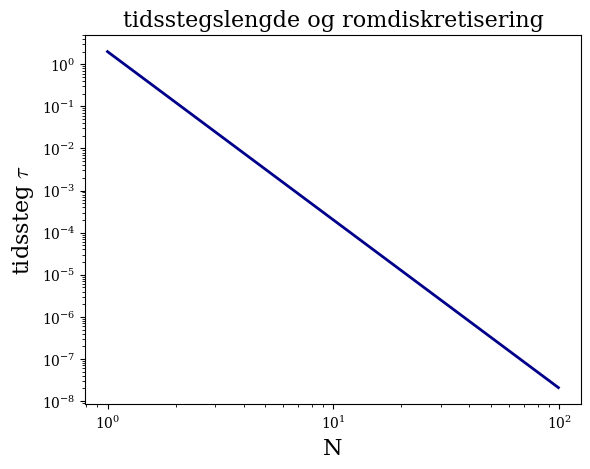

In [155]:
N = np.arange(1,100)
plt.loglog(N,2/N**4, color ="darkblue")
plt.grid()
plt.title("tidsstegslengde og romdiskretisering")
plt.xlabel("N")
plt.ylabel(r'tidssteg $\tau$')
plt.show()

In [156]:
N_cfl = 80000

Nt_list = [int(0.5*N_cfl), N_cfl, 2*N_cfl,4*N_cfl]

errs3, eocs3 = compute_eoc_transient(kappa=kappa, 
                                   u_ex=u0, U0=U0, g=g,
                                   X=X, Y=Y, t0=t0,theta=0, T=T, Nt_list=Nt_list) 

display(Markdown(r"### 📊 Konvergenstabell for $\theta = 0$"))
table = pd.DataFrame({'Nt': Nt_list, 'error': errs3, 'EOC': eocs3})
display(table)

100%|██████████| 1.000000000001004/1 [00:04<00:00,  4.85s/it]   
100%|█████████▉| 0.9999999999993368/1 [00:09<00:00,  9.13s/it]  
100%|█████████▉| 0.9999999999985031/1 [00:17<00:00, 17.22s/it]  
100%|█████████▉| 0.9999999999980863/1 [00:33<00:00, 33.09s/it]  


### 📊 Konvergenstabell for $\theta = 0$

,Nt,error,EOC
0,40000,0.000232,inf
1,80000,0.000116,1.000030
2,160000,0.000058,1.000015
3,320000,0.000029,1.000008
